In [4]:
# Core libraries for data manipulation, numerical operations, visualization, and statistical plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent default dimensions and font size for notebook visualizations
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

In [5]:
# Load the Superstore transaction dataset into a Pandas DataFrame
df = pd.read_csv(r"SuperStoreSales.csv")

# Preview the first few records to verify that the dataset loaded correctly
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
# Inspect the available columns and understand the structure of the dataset
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [7]:
# Check the number of rows and columns in the dataset
df.shape

(9800, 18)

In [8]:
# Generate descriptive statistics for the numerical columns
# This helps identify distributions, ranges, and potential outliers
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [9]:
# Inspect column data types and non-null counts to identify missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [10]:
# Check for completely duplicated rows before starting the analysis
df.duplicated().sum()

np.int64(0)

In [11]:
# Convert order and shipping dates from strings to datetime objects
# dayfirst=True matches the date format used in the dataset
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'],dayfirst=True)

# Calculate the number of days between placing an order and shipping it
df['Shipping Days'] = (df['Ship Date']-df['Order Date']).dt.days
df['Shipping Days']

0       3
1       3
2       4
3       7
4       7
       ..
9795    7
9796    5
9797    5
9798    5
9799    5
Name: Shipping Days, Length: 9800, dtype: int64

In [12]:
# Create time-based features for yearly, monthly, and month-level trend analysis
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order YearMonth'] = df['Order Date'].dt.to_period('M')

In [13]:
# Calculate high-level business KPIs from the transaction data
# Unique orders and customers are counted using their respective IDs
total_sales = df['Sales'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
avg_order_value = total_sales / total_orders

In [14]:
# Display the main business KPIs in a readable format
print("==========================================")
print("       SUPERSTORE HIGH-LEVEL KPIs         ")
print("==========================================")
print(f" Total Sales Revenue   : ${total_sales:,.2f}")
print(f" Total Unique Orders   : {total_orders:,}")
print(f" Total Unique Customers: {total_customers:,}")
print(f" Average Order Value   : ${avg_order_value:,.2f}")
print("==========================================")

       SUPERSTORE HIGH-LEVEL KPIs         
 Total Sales Revenue   : $2,261,536.78
 Total Unique Orders   : 4,922
 Total Unique Customers: 793
 Average Order Value   : $459.48


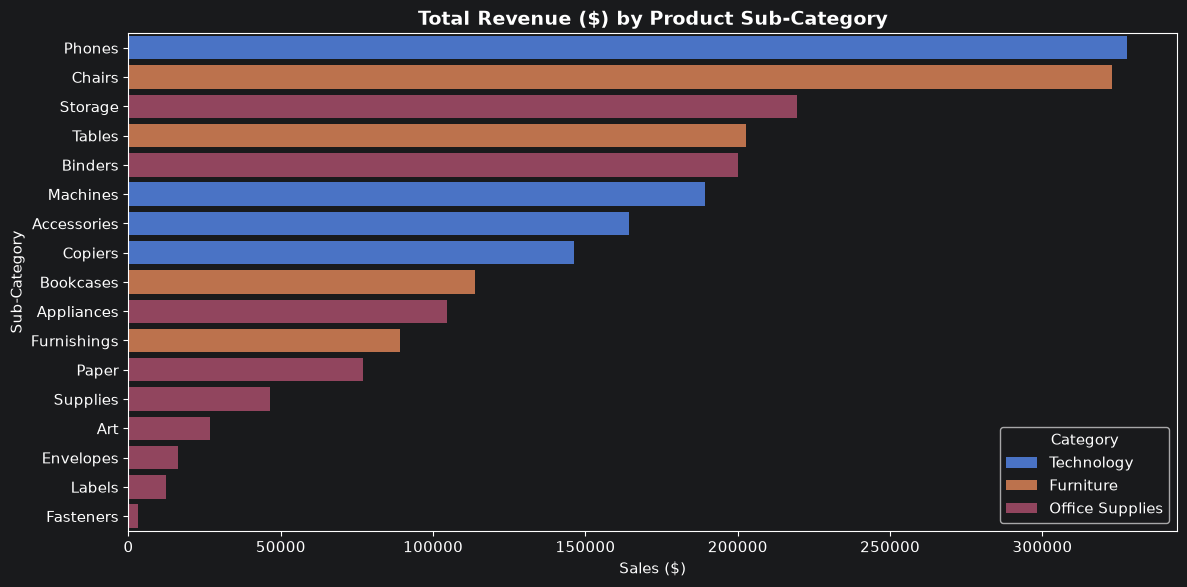

,Category,Sub-Category,Total Sales,Order Count
16,Technology,Phones,327782.4480,876
1,Furniture,Chairs,322822.7310,607
11,Office Supplies,Storage,219343.3920,832
3,Furniture,Tables,202810.6280,314
6,Office Supplies,Binders,200028.7850,1492
15,Technology,Machines,189238.6310,115
13,Technology,Accessories,164186.7000,756
14,Technology,Copiers,146248.0940,66
0,Furniture,Bookcases,113813.1987,226
4,Office Supplies,Appliances,104618.4030,459


In [15]:
# Aggregate revenue and transaction count by product category and sub-category
# Sorting by revenue makes the highest-performing product lines easy to identify
subcat_sales = df.groupby(['Category', 'Sub-Category'])['Sales'].agg(['sum', 'count']).reset_index()
subcat_sales.columns = ['Category', 'Sub-Category', 'Total Sales', 'Order Count']
subcat_sales = subcat_sales.sort_values(by='Total Sales', ascending=False)

# Visualize total revenue generated by each product sub-category
plt.figure(figsize=(12, 6))
sns.barplot(data=subcat_sales, y='Sub-Category', x='Total Sales', hue='Category', dodge=False)
plt.title('Total Revenue ($) by Product Sub-Category', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

# Display the aggregated table for detailed comparison
display(subcat_sales)

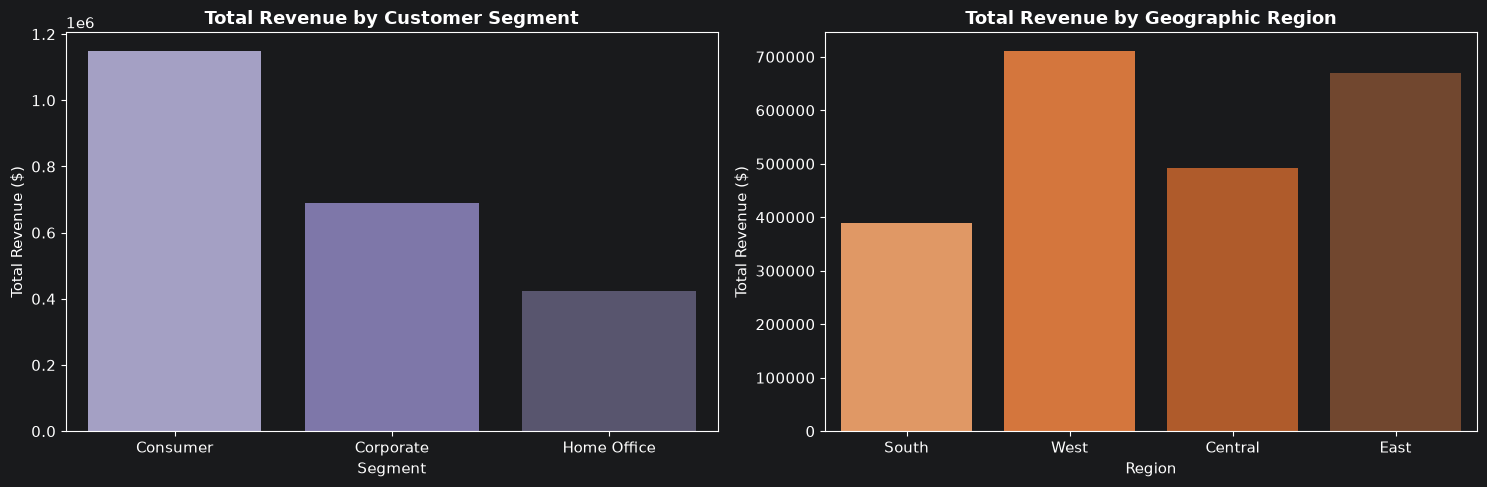

In [16]:
# Compare total revenue across customer segments and geographic regions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Customer segment revenue
sns.barplot(data=df, x='Segment', y='Sales', ax=axes[0], estimator=sum, errorbar=None, palette='Purples_d',hue = 'Segment')
axes[0].set_title('Total Revenue by Customer Segment', fontweight='bold')
axes[0].set_ylabel('Total Revenue ($)')

# Regional revenue
sns.barplot(data=df, x='Region', y='Sales', ax=axes[1], estimator=sum, errorbar=None, palette='Oranges_d',hue='Region')
axes[1].set_title('Total Revenue by Geographic Region', fontweight='bold')
axes[1].set_ylabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

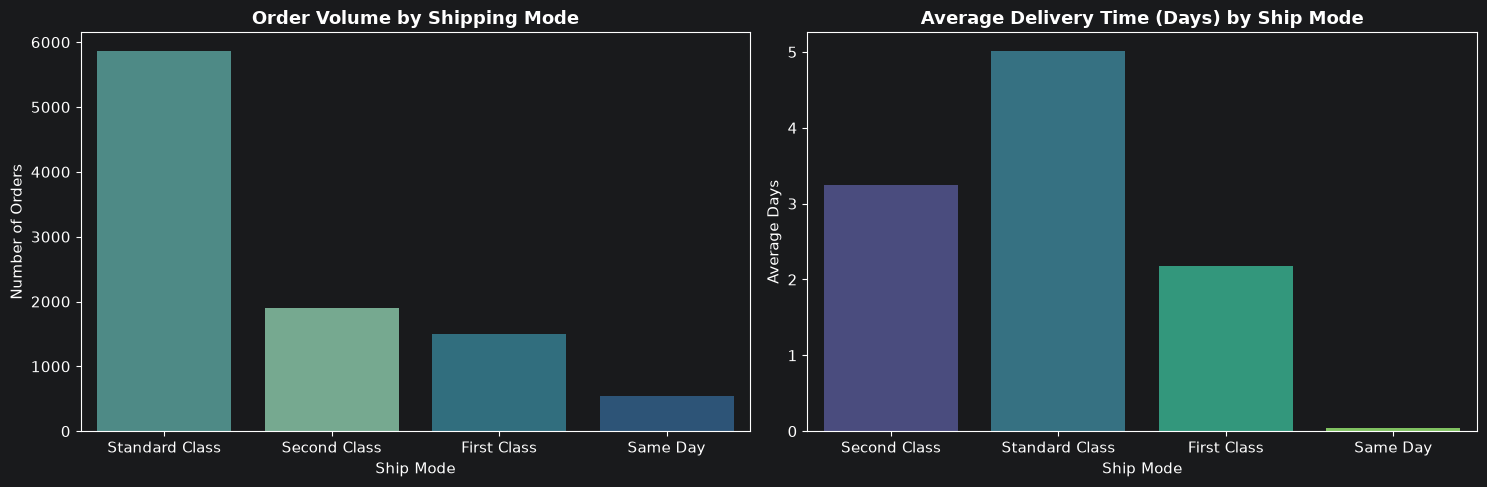

In [17]:
# Analyze shipping-method usage and average fulfillment time
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Count transactions for each shipping method
sns.countplot(data=df, x='Ship Mode', ax=axes[0], palette='crest', order=df['Ship Mode'].value_counts().index,hue = 'Ship Mode')
axes[0].set_title('Order Volume by Shipping Mode', fontweight='bold')
axes[0].set_ylabel('Number of Orders')

# Compare average shipping time across shipping methods
sns.barplot(data=df, x='Ship Mode', y='Shipping Days', ax=axes[1], palette='viridis', errorbar=None,hue='Ship Mode')
axes[1].set_title('Average Delivery Time (Days) by Ship Mode', fontweight='bold')
axes[1].set_ylabel('Average Days')

plt.tight_layout()
plt.show()

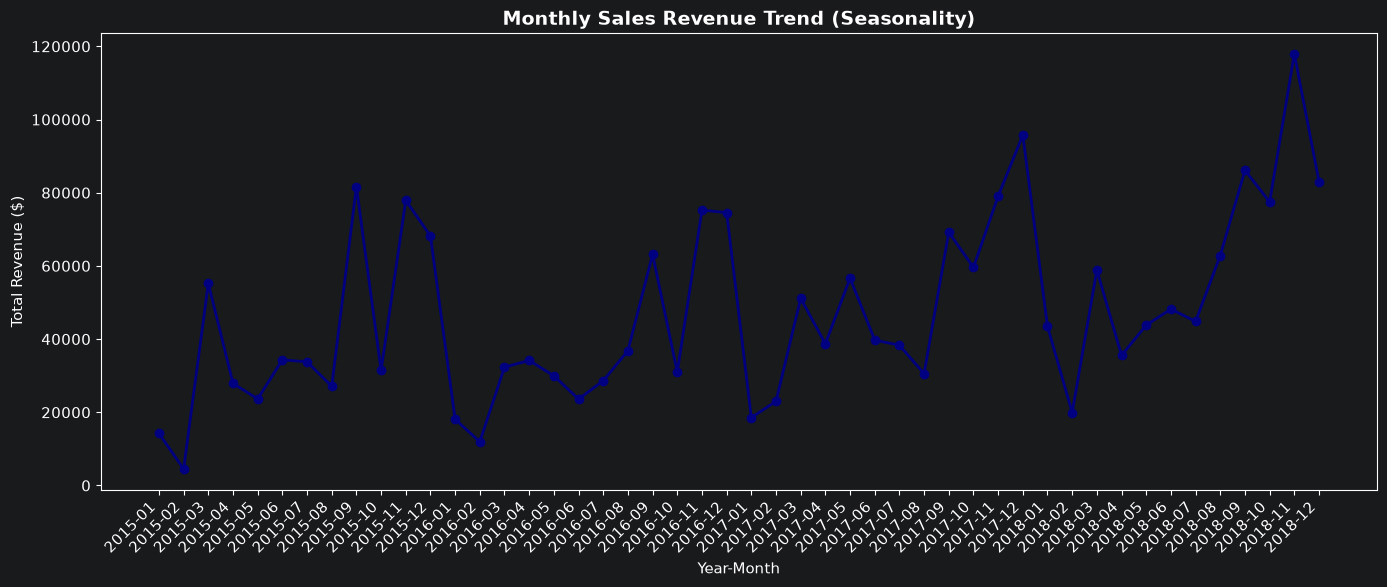

In [18]:
# Aggregate sales by month to reveal long-term trends and possible seasonality
monthly_sales = df.groupby('Order YearMonth')['Sales'].sum().reset_index()
monthly_sales['Order YearMonth'] = monthly_sales['Order YearMonth'].astype(str)

# Plot the monthly revenue trend
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Order YearMonth'], monthly_sales['Sales'], marker='o', color='navy', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Sales Revenue Trend (Seasonality)', fontsize=14, fontweight='bold')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

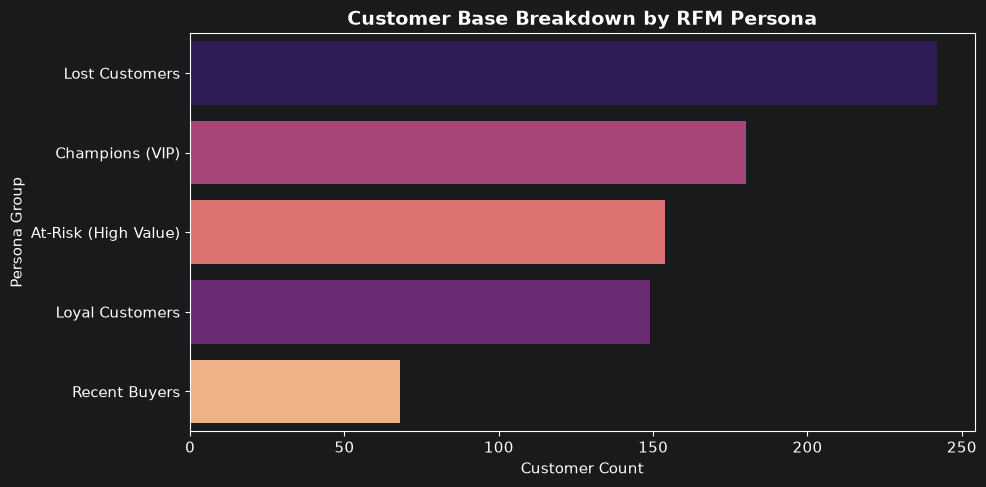

,Recency,Frequency,Monetary
Persona,,,
At-Risk (High Value),183.29,7.95,3777.15
Champions (VIP),32.71,8.66,4507.40
Lost Customers,317.31,4.07,1787.87
Loyal Customers,32.65,6.24,2168.72
Recent Buyers,38.46,3.31,1657.65


In [19]:
# Use the day after the latest order as the reference date for Recency
# This ensures the most recent customer activity receives a Recency of 1 day
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

# Build customer-level RFM metrics:
# Recency  = days since the customer's most recent order
# Frequency = number of unique orders placed
# Monetary = total sales generated by the customer
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (snapshot_date - x.max()).days,
    'Order ID': 'nunique',
    'Sales': 'sum'
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

# Convert each RFM metric into a quartile score from 1 to 4.
# Recency is reversed because a lower number of days means a more recent customer.
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])


# Assign each customer to a business-oriented persona based on their RFM scores
def assign_persona(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions (VIP)'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f == 1:
        return 'Recent Buyers'
    elif r <= 2 and f >= 3:
        return 'At-Risk (High Value)'
    else:
        return 'Lost Customers'

# Apply the segmentation rules to every customer
rfm['Persona'] = rfm.apply(assign_persona, axis=1)

# Visualize the size of each customer persona
plt.figure(figsize=(10, 5))
sns.countplot(data=rfm, y='Persona', palette='magma', order=rfm['Persona'].value_counts().index,hue='Persona')
plt.title('Customer Base Breakdown by RFM Persona', fontsize=14, fontweight='bold')
plt.xlabel('Customer Count')
plt.ylabel('Persona Group')
plt.tight_layout()
plt.show()

# Compare the average RFM metrics across customer personas
display(rfm.groupby('Persona')[['Recency', 'Frequency', 'Monetary']].mean().round(2))

# 📌 Executive Summary & Key Strategic Insights

### 1. Revenue Drivers & Product Performance
* **Top Sub-Categories:** **Phones** and **Chairs** generate the highest total revenue among all product lines.
* **Core Category:** **Technology** consistently drives top-line growth across all geographic regions.

### 2. Geographic & Segment Distribution
* **Regional Dominance:** The **West** and **East** regions account for over 60% of total company revenue.
* **Primary Customer Segment:** The **Consumer** segment represents ~50% of total revenue volume.

### 3. Fulfillment & Logistics
* **Standard Class** is the most widely chosen shipping method, averaging **4 to 5 days** for fulfillment.
* **Same Day** delivery operates within a <1 day window, proving logistical efficiency for priority orders.

### 4. Customer RFM Persona Action Plan
* **Champions (VIP):** Highly engaged with high monetary value. Target with early-access sales and loyalty perks.
* **At-Risk Customers:** High historical spenders who haven't ordered recently. Priority targets for automated win-back marketing campaigns.

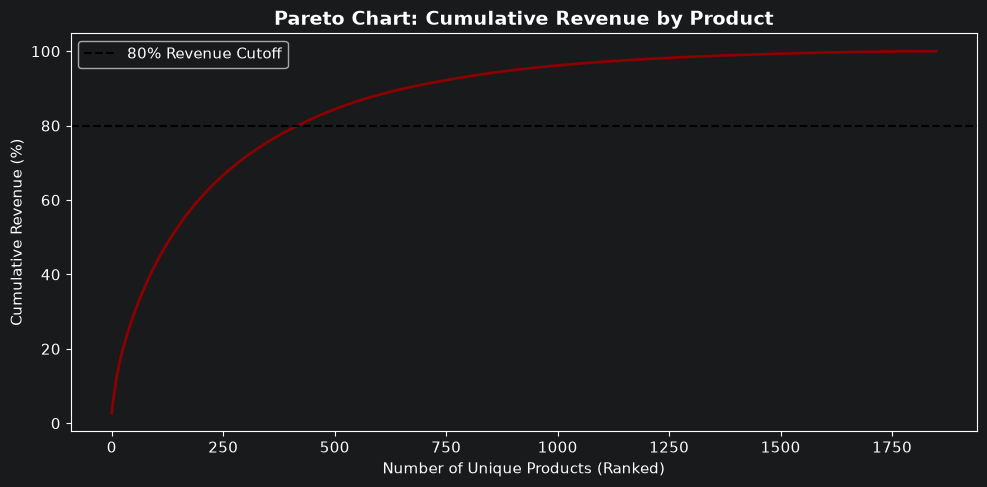

The top 20% of products (369 items) generate 76.97% of total sales.


In [20]:
# Aggregate product revenue and rank products from highest to lowest sales
product_sales = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).reset_index()

# Calculate cumulative revenue to determine how concentrated sales are among top products
product_sales['Cumulative_Sales'] = product_sales['Sales'].cumsum()
product_sales['Cumulative_Percent'] = (product_sales['Cumulative_Sales'] / product_sales['Sales'].sum()) * 100

# Plot the cumulative revenue curve and mark the 80% revenue threshold
plt.figure(figsize=(10, 5))
plt.plot(product_sales.index, product_sales['Cumulative_Percent'], color='darkred', linewidth=2)
plt.axhline(80, color='black', linestyle='--', label='80% Revenue Cutoff')
plt.title('Pareto Chart: Cumulative Revenue by Product', fontsize=14, fontweight='bold')
plt.xlabel('Number of Unique Products (Ranked)')
plt.ylabel('Cumulative Revenue (%)')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate the percentage of revenue generated by the top 20% of products
top_20_count = int(len(product_sales) * 0.2)
top_20_rev = product_sales.iloc[top_20_count]['Cumulative_Percent']
print(f"The top 20% of products ({top_20_count} items) generate {top_20_rev:.2f}% of total sales.")

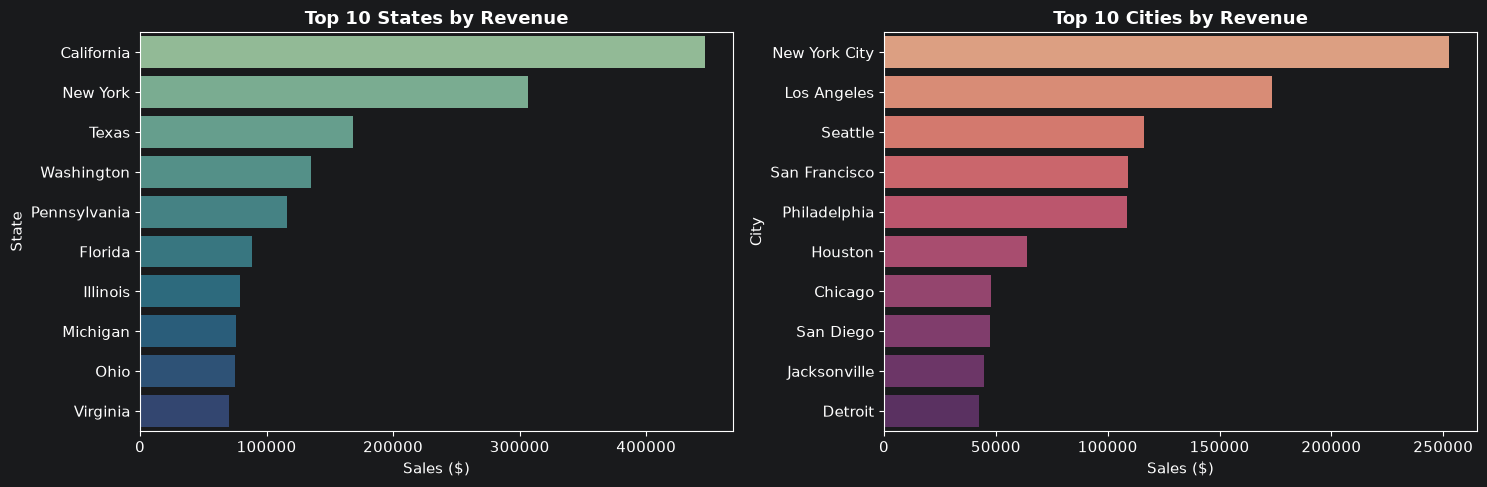

In [21]:
# Identify the top-performing states and cities by total revenue
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 10 states by sales
top_states = df.groupby('State')['Sales'].sum().nlargest(10).reset_index()
sns.barplot(data=top_states, y='State', x='Sales', ax=axes[0], palette='crest',hue='State')
axes[0].set_title('Top 10 States by Revenue', fontweight='bold')
axes[0].set_xlabel('Sales ($)')

# Top 10 cities by sales
top_cities = df.groupby('City')['Sales'].sum().nlargest(10).reset_index()
sns.barplot(data=top_cities, y='City', x='Sales', ax=axes[1], palette='flare',hue='City')
axes[1].set_title('Top 10 Cities by Revenue', fontweight='bold')
axes[1].set_xlabel('Sales ($)')

plt.tight_layout()
plt.show()

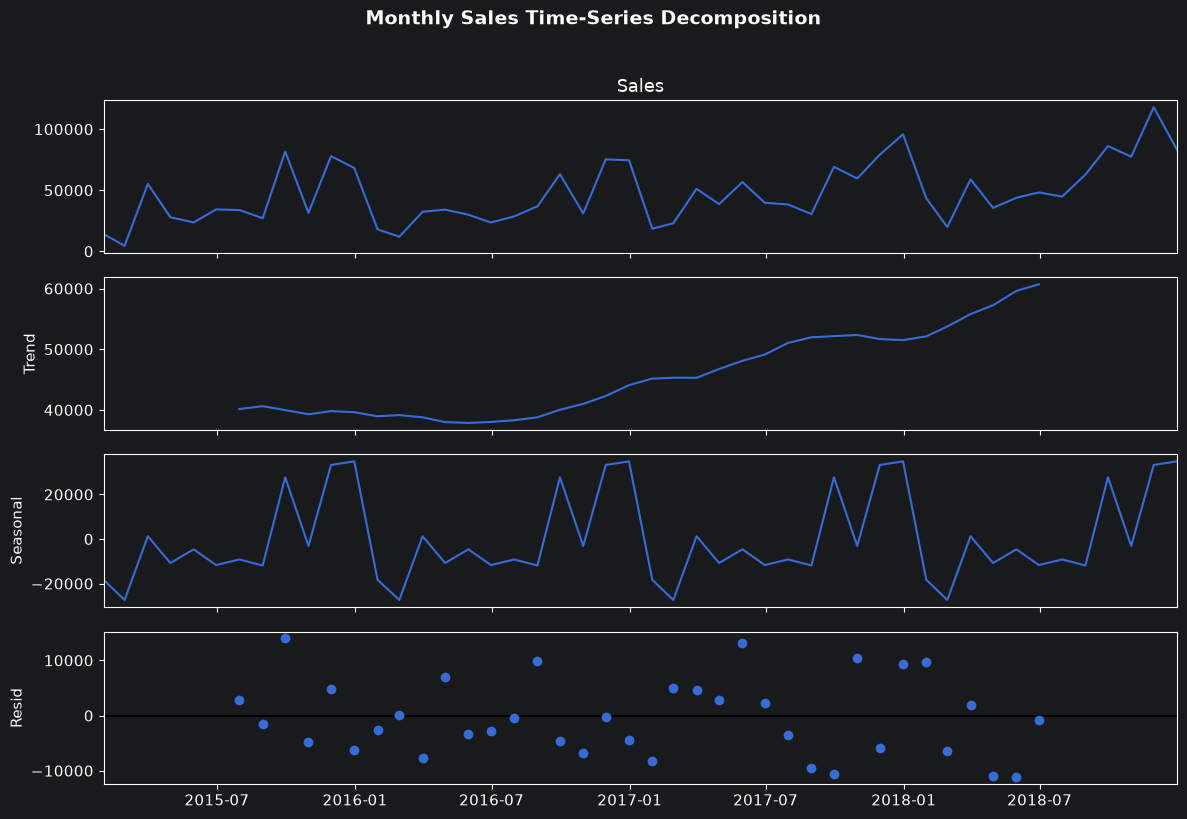

In [22]:
# Import the seasonal decomposition method for time-series analysis
from statsmodels.tsa.seasonal import seasonal_decompose


# Resample transaction-level sales into monthly totals
ts_monthly = df.set_index('Order Date')['Sales'].resample('ME').sum()

# Decompose monthly sales into observed, trend, seasonal, and residual components
decomposition = seasonal_decompose(ts_monthly, model='additive')

# Plot the four components to examine long-term trend and recurring seasonal effects
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Monthly Sales Time-Series Decomposition', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# Combine the three RFM scores into a single three-digit customer score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Attach customer-level persona and RFM score back to every transaction
df_merged = df.merge(rfm[['Customer ID', 'Persona', 'RFM_Score']], on='Customer ID', how='left')

# Export the enriched dataset for further analysis or BI dashboarding
df_merged.to_csv('superstore_processed_rfm.csv', index=False)

print("Exported 'superstore_processed_rfm.csv' successfully with RFM_Score!")

Exported 'superstore_processed_rfm.csv' successfully with RFM_Score!


# 📌 Advanced Analytics & Final Executive Summary

---

### 1. 🎯 Pareto Principle (80/20 Rule) & Product Concentration
* **Revenue Bottleneck:** The Pareto analysis reveals that roughly **20% of unique products generate ~80% of total company revenue**.
* **Actionable Takeaway:** Merchandising and inventory teams should prioritize maintaining stock levels for these core top-performing SKUs to prevent high-revenue stockouts, while considering sunsetting or bundling the long-tail 80% underperforming products.

---

### 2. 🗺️ Geographic Market Concentration
* **Top Revenue States:** **California** and **New York** lead gross revenue by a wide margin, driven by urban hubs like **New York City** and **Los Angeles**.
* **Actionable Takeaway:** Marketing spend and logistics investments yield the highest ROI when concentrated in the **West** and **East** coastal metro areas. Emerging states in the **South** require targeted promotional strategies to increase market penetration.

---

### 3. 📈 Time-Series Decomposition (Trend & Seasonality)
* **Underlying Growth Trend:** The multi-year trend line shows stable year-over-year revenue expansion.
* **Q4 Seasonality:** A clear, predictable seasonal peak occurs annually between **October and December** (Q4 holiday rush), followed by a sharp drop in **January**.
* **Actionable Takeaway:** Supply chain planning must scale up warehouse fulfillment capacity and carrier staffing starting in September to support peak Q4 demand smoothly.

---

### 4. 👥 Customer RFM Segment Strategy
| Persona | Characteristics | Strategic Action Plan |
| :--- | :--- | :--- |
| **Champions (VIP)** | High Recency, High Frequency, High Spend | Early-access products, VIP loyalty rewards, concierge support. |
| **Loyal Customers** | Steady repeat buyers with consistent spending | Upsell higher-margin categories (Technology), send product recommendations. |
| **At-Risk (High Value)** | Heavy historical spenders inactive recently | Automated "We Miss You" win-back email campaigns with 15–20% discounts. |
| **Recent Buyers** | New purchasers with low order counts | Welcome onboarding series to drive second purchase conversion. |
| **Lost Customers** | Low spenders inactive for extended periods | Suppress from high-cost ad campaigns to save marketing budget. |

---

### 💾 Data Integration & BI Dashboarding
* The fully processed dataset—complete with cleaned date fields, shipping metrics, RFM score strings, and customer persona tags—has been exported as **`superstore_processed_rfm.csv`**.
* This file is ready to be linked directly into **Power BI** or **Tableau** for interactive dashboard visualization.